# Objective
Analyzing e-commerce furniture data helps identify sales trends, customer preferences, and inventory demands. It optimizes pricing, marketing strategies, and supply chain efficiency while enhancing user experiences. This drives better decision-making, boosts revenue, and fosters customer satisfaction in competitive markets.

# Importing necessary libraries¶

In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

# Loading data

In [3]:
df = pd.read_csv("ecommerce_furniture_dataset_2024 (1).csv")

In [4]:
df

,productTitle,originalPrice,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,NaN,$46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,NaN,$169.72,0,Free shipping
2,Desser For Bedroom With 7 Fabric Drawers Organ...,$78.4,$39.46,7,Free shipping
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",NaN,$111.99,0,Free shipping
4,Small Unit Simple Computer Desk Household Wood...,$48.82,$21.37,1,Free shipping
...,...,...,...,...,...
1995,Modern TV Stand Entertainment Center with Two ...,NaN,$72.49,8,Free shipping
1996,"Large Wardrobe Armoire Closet with 3 Doors, Fr...",NaN,$276.65,2,Free shipping
1997,"Velvet Futon Sofa Bed, 73-inch Sleeper Couch w...",NaN,$196.44,10,Free shipping
1998,Furniture Acrylic Coffee Table Transparent Liv...,NaN,$228.18,0,Free shipping


In [5]:
#head method 
df.head()

,productTitle,originalPrice,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,NaN,$46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,NaN,$169.72,0,Free shipping
2,Desser For Bedroom With 7 Fabric Drawers Organ...,$78.4,$39.46,7,Free shipping
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",NaN,$111.99,0,Free shipping
4,Small Unit Simple Computer Desk Household Wood...,$48.82,$21.37,1,Free shipping


In [6]:
# tail method 
df.tail()

,productTitle,originalPrice,price,sold,tagText
1995,Modern TV Stand Entertainment Center with Two ...,NaN,$72.49,8,Free shipping
1996,"Large Wardrobe Armoire Closet with 3 Doors, Fr...",NaN,$276.65,2,Free shipping
1997,"Velvet Futon Sofa Bed, 73-inch Sleeper Couch w...",NaN,$196.44,10,Free shipping
1998,Furniture Acrylic Coffee Table Transparent Liv...,NaN,$228.18,0,Free shipping
1999,Bed Frane Bamboo and Metal Platform Bed Frame ...,NaN,$99.48,0,Free shipping


# Data processing

# Now we will check shape, dimension , columns 

In [7]:
df.shape

(2000, 5)

In [8]:
df.ndim

2

In [9]:
df.columns

Index(['productTitle', 'originalPrice', 'price', 'sold', 'tagText'], dtype='object')

In [10]:
df.dtypes

productTitle     object
originalPrice    object
price            object
sold              int64
tagText          object
dtype: object

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   productTitle   2000 non-null   object
 1   originalPrice  487 non-null    object
 2   price          2000 non-null   object
 3   sold           2000 non-null   int64 
 4   tagText        1997 non-null   object
dtypes: int64(1), object(4)
memory usage: 78.2+ KB


In [12]:
df['tagText'].nunique()

100

In [13]:
df['tagText'].value_counts()

Free shipping         1880
+Shipping: $5.09         9
+Shipping: $80.21        2
+Shipping: $239.64       2
+Shipping: $75.99        2
                      ... 
+Shipping: $41.93        1
+Shipping: $60.62        1
+Shipping: $85.58        1
+Shipping: $85.45        1
+Shipping: $134.27       1
Name: tagText, Length: 100, dtype: int64

# Handling missing values 

In [14]:
df.isnull().sum()

productTitle        0
originalPrice    1513
price               0
sold                0
tagText             3
dtype: int64

In [15]:
df.isna().sum()

productTitle        0
originalPrice    1513
price               0
sold                0
tagText             3
dtype: int64

In [16]:
df.fillna(0,inplace=True)

In [17]:
df.isnull().sum()

productTitle     0
originalPrice    0
price            0
sold             0
tagText          0
dtype: int64

In [18]:
df.describe()

,sold
count,2000.000000
mean,23.493500
std,254.094061
min,0.000000
25%,1.000000
50%,3.000000
75%,9.000000
max,10000.000000


In [19]:
df.dtypes

productTitle     object
originalPrice    object
price            object
sold              int64
tagText          object
dtype: object

In [ ]:
# Now we will convert object dtype of original price and price in float64 & tagText into category

In [20]:
df['originalPrice']=df['originalPrice'].str.replace('$','').str.replace(',','')

<ipython-input-20-13b2b121974e>:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will*not* be treated as literal strings when regex=True.
  df['originalPrice']=df['originalPrice'].str.replace('$','').str.replace(',','')


In [21]:
df['price']=df['price'].str.replace('$','').str.replace(',','')

<ipython-input-21-3de0ea9b42d6>:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will*not* be treated as literal strings when regex=True.
  df['price']=df['price'].str.replace('$','').str.replace(',','')


In [22]:
df['originalPrice']=pd.to_numeric(df['originalPrice'])

In [23]:
df['price']=pd.to_numeric(df['price'])

In [24]:
df.dtypes

productTitle      object
originalPrice    float64
price            float64
sold               int64
tagText           object
dtype: object

In [25]:
df

,productTitle,originalPrice,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,NaN,46.79,600,Free shipping
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,NaN,169.72,0,Free shipping
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.40,39.46,7,Free shipping
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",NaN,111.99,0,Free shipping
4,Small Unit Simple Computer Desk Household Wood...,48.82,21.37,1,Free shipping
...,...,...,...,...,...
1995,Modern TV Stand Entertainment Center with Two ...,NaN,72.49,8,Free shipping
1996,"Large Wardrobe Armoire Closet with 3 Doors, Fr...",NaN,276.65,2,Free shipping
1997,"Velvet Futon Sofa Bed, 73-inch Sleeper Couch w...",NaN,196.44,10,Free shipping
1998,Furniture Acrylic Coffee Table Transparent Liv...,NaN,228.18,0,Free shipping


In [26]:
df['tagText']=df['tagText'].astype('category').cat.codes

In [27]:
df.fillna(0,inplace=True)

In [28]:
df

,productTitle,originalPrice,price,sold,tagText
0,Dresser For Bedroom With 9 Fabric Drawers Ward...,0.00,46.79,600,100
1,Outdoor Conversation Set 4 Pieces Patio Furnit...,0.00,169.72,0,100
2,Desser For Bedroom With 7 Fabric Drawers Organ...,78.40,39.46,7,100
3,"Modern Accent Boucle Chair,Upholstered Tufted ...",0.00,111.99,0,100
4,Small Unit Simple Computer Desk Household Wood...,48.82,21.37,1,100
...,...,...,...,...,...
1995,Modern TV Stand Entertainment Center with Two ...,0.00,72.49,8,100
1996,"Large Wardrobe Armoire Closet with 3 Doors, Fr...",0.00,276.65,2,100
1997,"Velvet Futon Sofa Bed, 73-inch Sleeper Couch w...",0.00,196.44,10,100
1998,Furniture Acrylic Coffee Table Transparent Liv...,0.00,228.18,0,100


# Exploratory Data Analysis
Now that our data is clean, let's perform some exploratory data analysis to understand the distribution and relationship with data 

In [29]:
# Summary statistics
df.describe()

,originalPrice,price,sold,tagText
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,62.342840,156.560020,23.493500,97.098500
std,235.644916,176.936735,254.094061,13.501961
min,0.000000,0.990000,0.000000,0.000000
25%,0.000000,48.530000,1.000000,100.000000
50%,0.000000,114.080000,3.000000,100.000000
75%,0.000000,193.490000,9.000000,100.000000
max,3265.130000,2876.380000,10000.000000,100.000000


In [30]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn

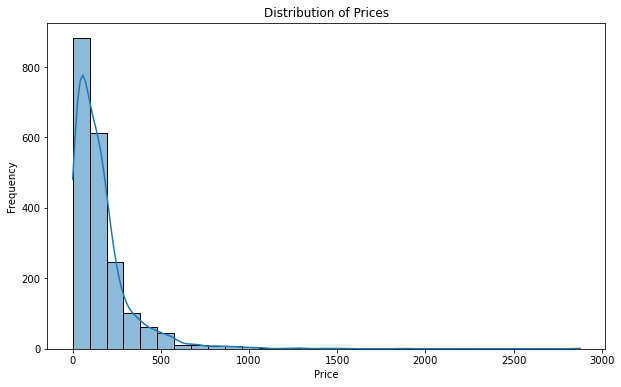

In [31]:
# Distribution of prices
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

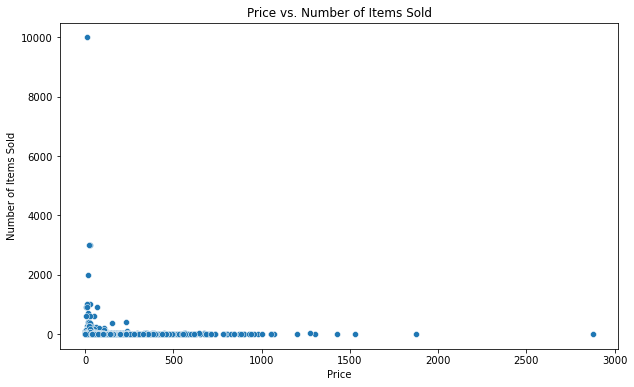

In [32]:
# Relationship between price and number of items sold
plt.figure(figsize=(10, 6))
sns.scatterplot(x='price', y='sold', data=df)
plt.title('Price vs. Number of Items Sold')
plt.xlabel('Price')
plt.ylabel('Number of Items Sold')
plt.show()

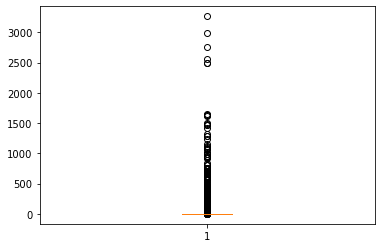

In [33]:
# for original price feature 
plt.boxplot(df['originalPrice'])
plt.show()

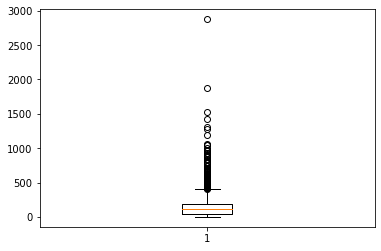

In [34]:
# for price feature
plt.boxplot(df['price'])
plt.show()

# Visualization

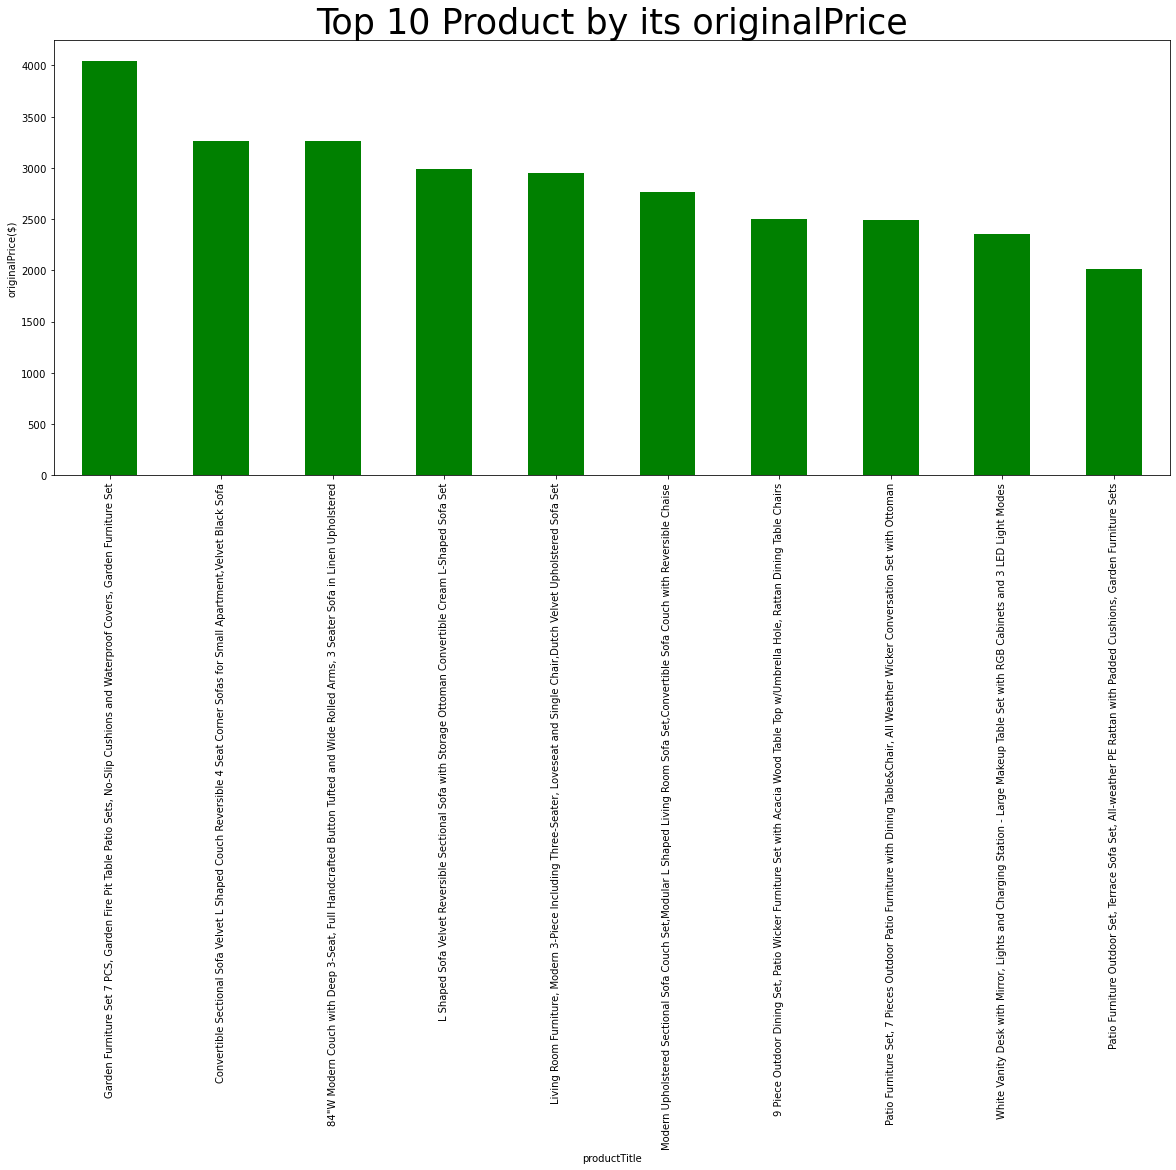

In [35]:
plt.figure(figsize=(20,8))
df.groupby('productTitle')["originalPrice"].sum().sort_values(ascending=False).head(10).plot(kind='bar',color='green')
plt.title('Top 10 Product by its originalPrice',size=35)
plt.ylabel('originalPrice($)')
plt.show()

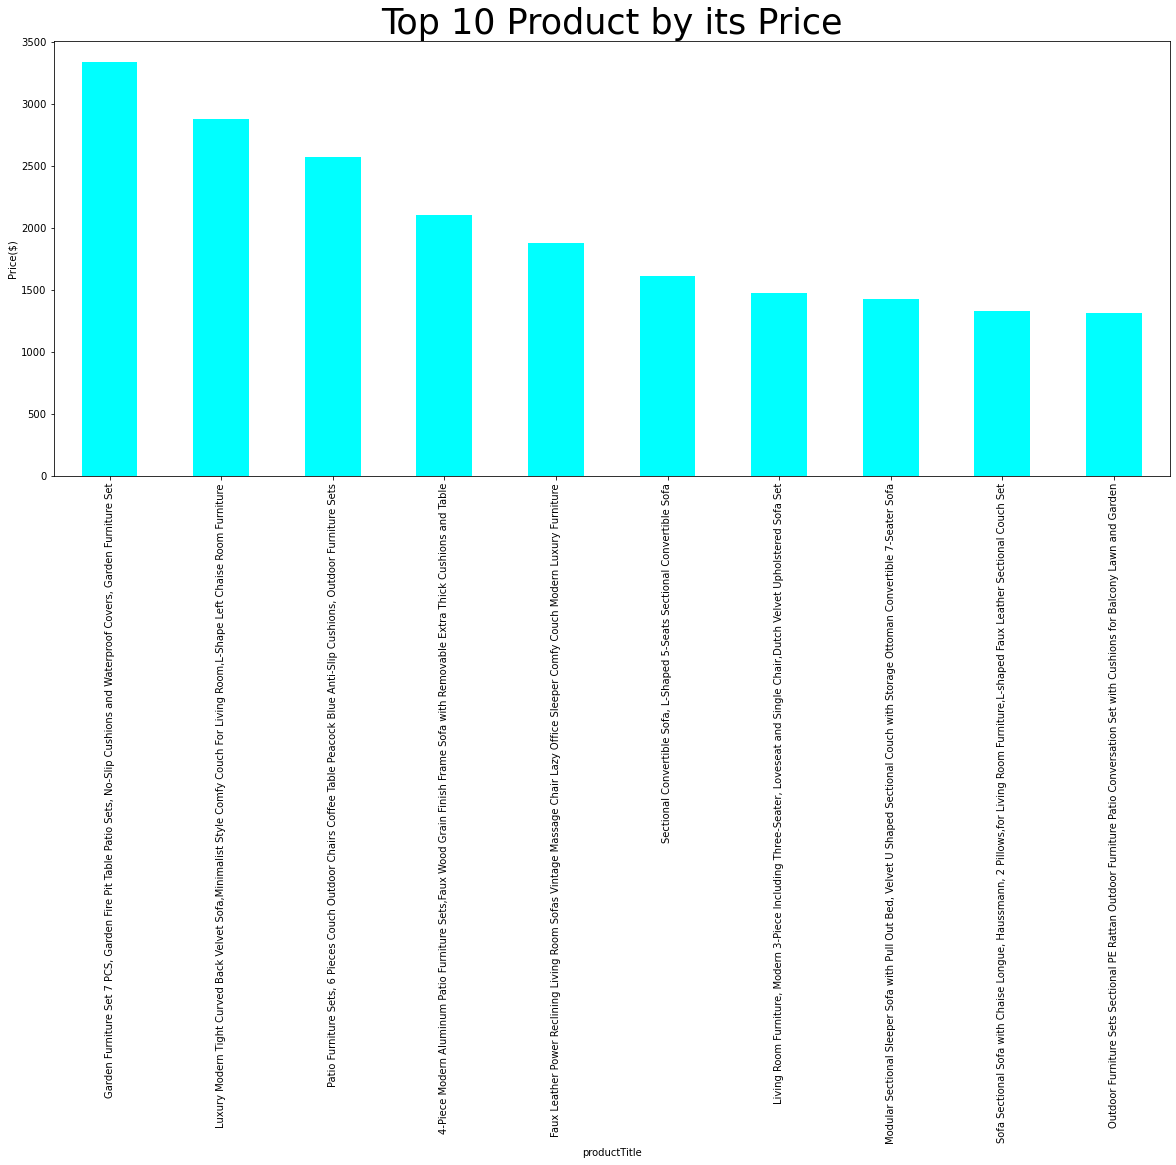

In [36]:
plt.figure(figsize=(20,8))
df.groupby('productTitle')["price"].sum().sort_values(ascending=False).head(10).plot(kind='bar',color='cyan')
plt.title('Top 10 Product by its Price',size=35)
plt.ylabel('Price($)')
plt.show()

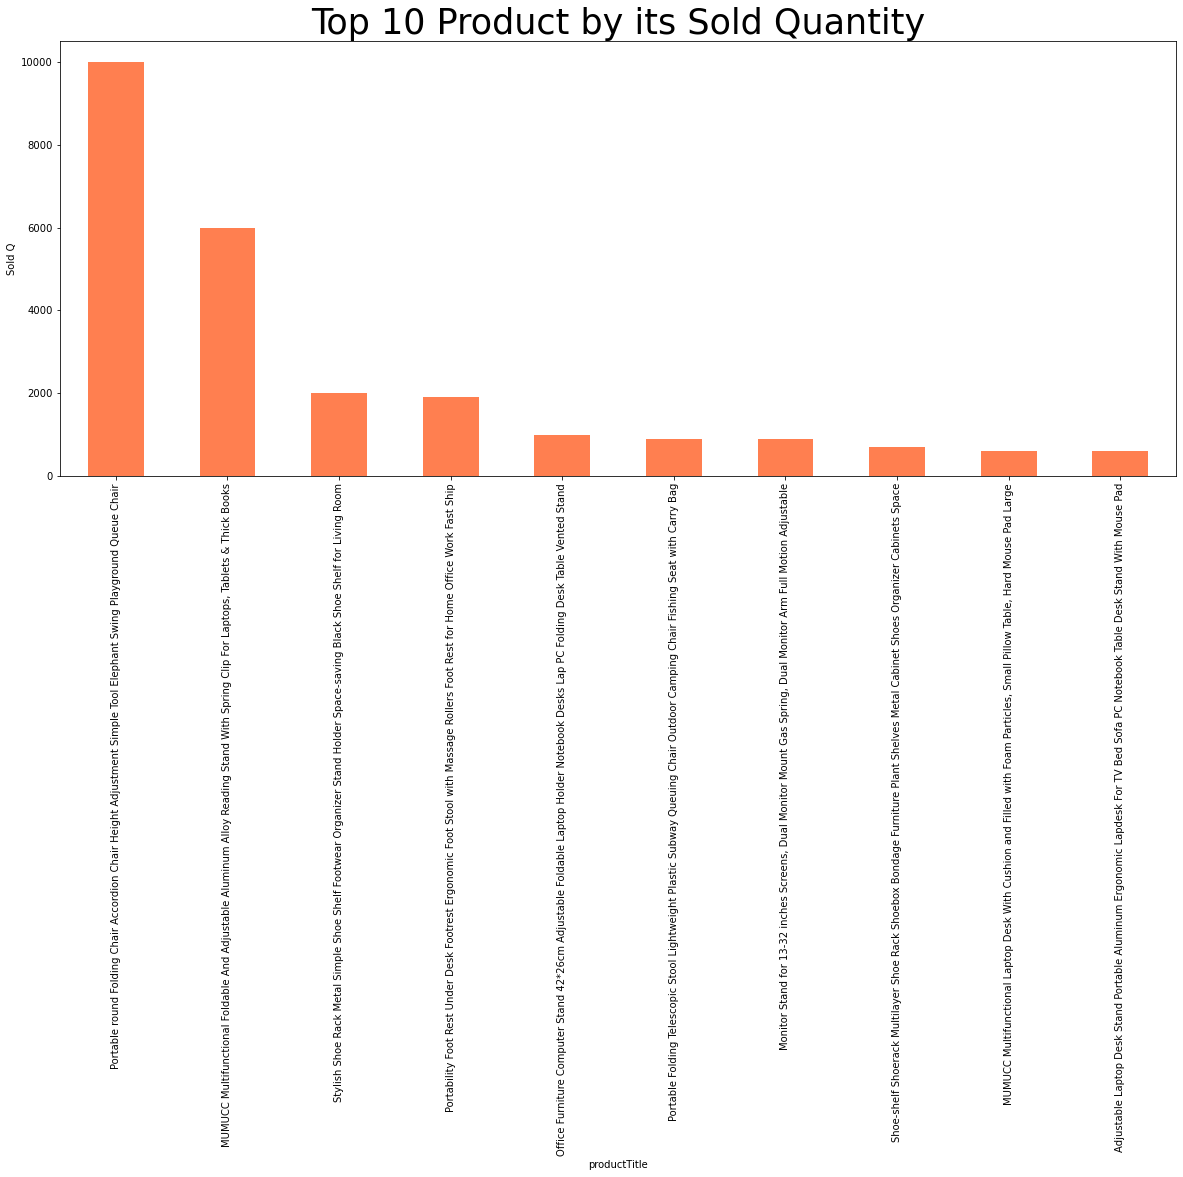

In [38]:
plt.figure(figsize=(20,8))
df.groupby('productTitle')["sold"].sum().sort_values(ascending=False).head(10).plot(kind='bar',color='coral')
plt.title('Top 10 Product by its Sold Quantity',size=35)
plt.ylabel('Sold Q')
plt.show()

# Conclusion
In this starter-code notebook, we have loaded, cleaned, and performed exploratory data analysis on the E-commerce Furniture Dataset for 2024. We have visualized the distribution of prices and examined the relationship between price and the number of items sold. Further analysis can be conducted to uncover more insights and trends.

